**Import Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Load Data**

In [3]:
import pandas as pd
df= pd.read_csv(r"C:\Users\graja\Documents\Sales analysis project\data\sales_data.csv")

**Basic Overview**

In [6]:
print("\nfirst 5 rows:\n",df.head())
print("\nDataset Info:\n", df.info())


first 5 rows:
    Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052  2023-02-03       Bob  North       5053.97             18   
1        1093  2023-04-21       Bob   West       4384.02             17   
2        1015  2023-09-21     David  South       4631.23             30   
3        1072  2023-08-24       Bob  South       2167.94             39   
4        1061  2023-03-24   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  
0           Cash        Online            North-Bob  
1         

**Data Cleaning & Validation**

Check duplicates

In [10]:
duplicates= df.duplicated().sum()
print(f"\nDuplicate Rows:{duplicates}")


Duplicate Rows:0


Convert Sale_Date column

In [19]:
df["Sale_Date"]= pd.to_datetime(df["Sale_Date"])
df.dtypes

Product_ID                       int64
Sale_Date               datetime64[ns]
Sales_Rep                       object
Region                          object
Sales_Amount                   float64
Quantity_Sold                    int64
Product_Category                object
Unit_Cost                      float64
Unit_Price                     float64
Customer_Type                   object
Discount                       float64
Payment_Method                  object
Sales_Channel                   object
Region_and_Sales_Rep            object
dtype: object

**Feature Engineering**

In [22]:
df["Month"]= df["Sale_Date"].dt.month
df["Year"]= df["Sale_Date"].dt.year
df.dtypes

Product_ID                       int64
Sale_Date               datetime64[ns]
Sales_Rep                       object
Region                          object
Sales_Amount                   float64
Quantity_Sold                    int64
Product_Category                object
Unit_Cost                      float64
Unit_Price                     float64
Customer_Type                   object
Discount                       float64
Payment_Method                  object
Sales_Channel                   object
Region_and_Sales_Rep            object
Month                            int32
Year                             int32
dtype: object

Profit Calculation

In [26]:
df["Profit"]= (df["Unit_Price"]-df["Unit_Cost"])*df["Quantity_Sold"]

**DATA ANALYSIS**

Top Categories

In [34]:
top_categories= df.groupby("Product_Category")["Sales_Amount"].sum().sort_values(ascending=False)
print(top_categories)

Product_Category
Clothing       1313474.36
Furniture      1260517.69
Electronics    1243499.64
Food           1201773.54
Name: Sales_Amount, dtype: float64


Sales By Region

In [28]:
region_sales= df.groupby("Region")["Sales_Amount"].sum().sort_values(ascending=False)
print(region_sales)

Region
North    1369612.51
East     1259792.93
West     1235608.93
South    1154250.86
Name: Sales_Amount, dtype: float64


Monthly Sales

In [30]:
monthly_sales= df.groupby("Month")["Sales_Amount"].sum()
print(monthly_sales)

Month
1     495420.37
2     368919.36
3     402638.77
4     438992.61
5     389078.76
6     418458.34
7     374242.88
8     443171.28
9     367837.60
10    460378.78
11    467482.90
12    392643.58
Name: Sales_Amount, dtype: float64


Top_Sales_Rep

In [31]:
top_reps= df.groupby("Sales_Rep")["Sales_Amount"].sum().sort_values(ascending=False)
print(top_reps)

Sales_Rep
David      1141737.36
Bob        1080990.63
Eve         970183.99
Alice       965541.77
Charlie     860811.48
Name: Sales_Amount, dtype: float64


Profit By Region

In [32]:
profit_region= df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
print(profit_region)

Region
North    1661461.20
West     1656091.77
East     1650557.20
South    1519736.90
Name: Profit, dtype: float64


Payment Method Analysis

In [33]:
payment_sales= df.groupby("Payment_Method")["Sales_Amount"].sum()
print(payment_sales)



Payment_Method
Bank Transfer    1717363.17
Cash             1544338.54
Credit Card      1757563.52
Name: Sales_Amount, dtype: float64


**Visualization**

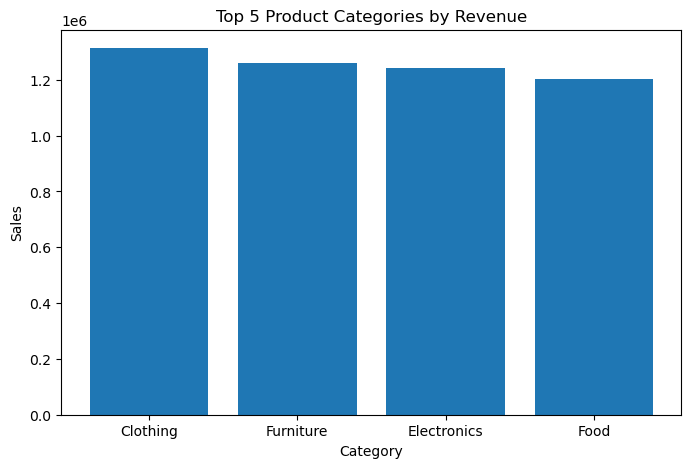

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(top_categories.index[:5],top_categories.values[:5])
plt.title("Top 5 Product Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

Sales By Region

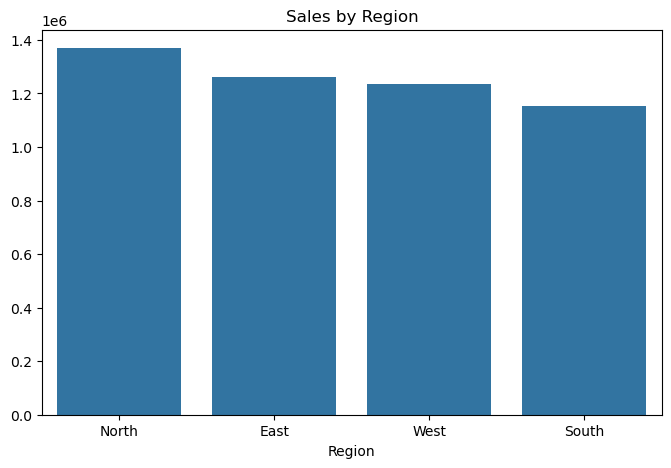

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index,y=region_sales.values)
plt.title("Sales by Region")
plt.show()

Monthly Sales Trend

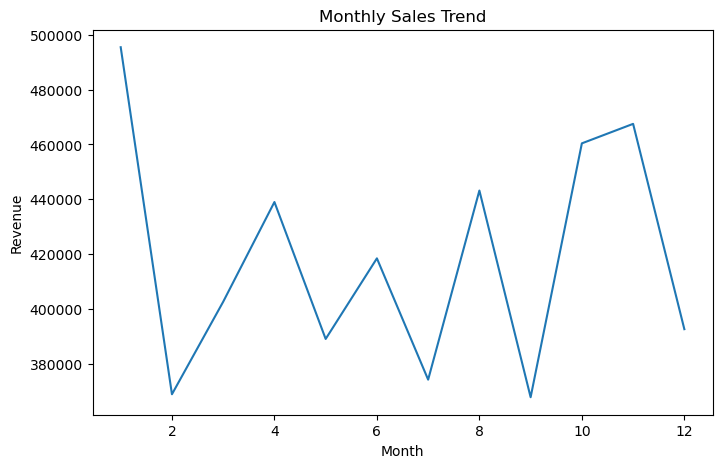

In [41]:
plt.figure(figsize=(8,5))
sns.lineplot(x=monthly_sales.index,y=monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Top Sales Representatives

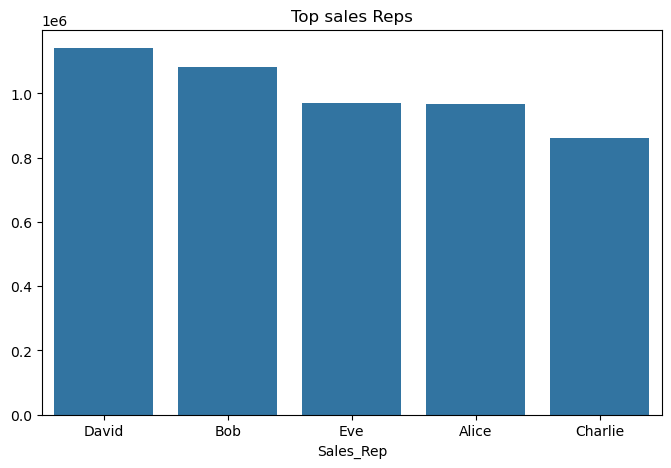

In [47]:
plt.figure(figsize=(8,5))
sns.barplot(x=top_reps.index, y=top_reps.values)
plt.title("Top sales Reps")
plt.show()

Profit by Region

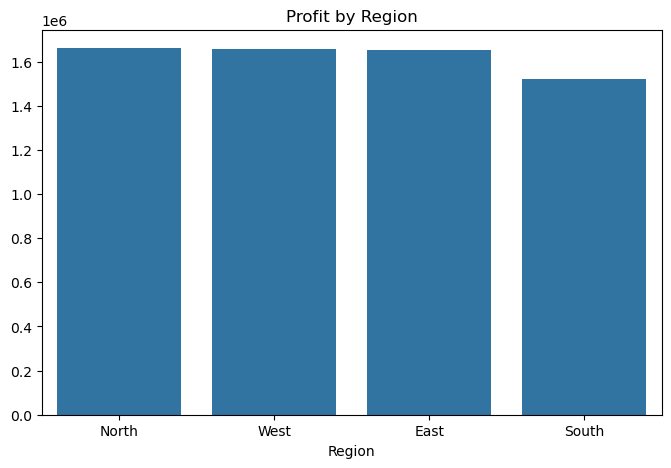

In [48]:
plt.figure(figsize=(8,5))
sns.barplot(x=profit_region.index, y=profit_region.values)
plt.title("Profit by Region")
plt.show()

Payment Method Analysis

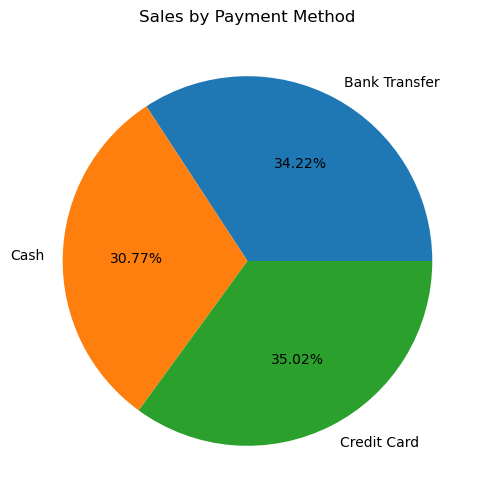

In [53]:
plt.figure(figsize=(6,6))
plt.pie(payment_sales.values, labels=payment_sales.index, autopct="%1.2f%%")
plt.title("Sales by Payment Method")
plt.show()


**Key Insights**

In [57]:
print("\n Key Insights:")
print(f"Top Category: {top_categories.idxmax()}")
print(f"Top Region (Sales): {region_sales.idxmax()}")
print(f"Top Sales Rep: {top_reps.idxmax()}")
print(f"Best Month: {monthly_sales.idxmax()}")
print(f"Highest Profit Region: {profit_region.idxmax()}")
print(f"Most Used Payment Method: {payment_sales.idxmax()}")


 Key Insights:
Top Category: Clothing
Top Region (Sales): North
Top Sales Rep: David
Best Month: 1
Highest Profit Region: North
Most Used Payment Method: Credit Card
